In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import plotly.graph_objects as go
import mplfinance as mpf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import cross_val_score
from tvDatafeed import TvDatafeed, Interval
import matplotlib.pyplot as plt


In [29]:
username = 'vaxebef549@artgulin.com'
password = 'vaxebef549@artgulin.com'

tv = TvDatafeed()

# Get BTCUSDT data
btcusdt_binance_data = tv.get_hist(symbol='BTCUSDT', exchange='BINANCE', interval=Interval.in_5_minute, n_bars=10000)

# Convert data to DataFrame
btcusdt_df = pd.DataFrame(btcusdt_binance_data)

# Reset index to include datetime in DataFrame
btcusdt_df.reset_index(inplace=True)

# Crear el nombre del archivo
# Extraer los valores para el nombre del archivo
symbol = 'BTC'
exchange = 'BINANCE'
interval = '1d'
n_bars = 10000
filename = f"{symbol}_{exchange}_{interval}_{n_bars}.csv"

# Guardar DataFrame en el archivo CSV
btcusdt_df.to_csv(filename, index=False)

print(f"Datos de {symbol} guardados como '{filename}'")

btcusdt_df.head()


Datos de BTC guardados como 'BTC_BINANCE_1d_10000.csv'


,datetime,symbol,open,high,low,close,volume
0,2024-05-05 19:00:00,BINANCE:BTCUSDT,64012.00,64105.00,64011.01,64088.00,72.53531
1,2024-05-05 19:05:00,BINANCE:BTCUSDT,64088.01,64130.00,64066.00,64130.00,34.04154
2,2024-05-05 19:10:00,BINANCE:BTCUSDT,64129.99,64132.84,64084.00,64091.34,22.54839
3,2024-05-05 19:15:00,BINANCE:BTCUSDT,64091.33,64173.44,64068.00,64162.00,61.20721
4,2024-05-05 19:20:00,BINANCE:BTCUSDT,64162.00,64346.24,64152.20,64249.41,97.15320


In [30]:
# Cargar los datos
df = pd.read_csv('D:/iqrobot/BTC_BINANCE_1d_10000.csv', parse_dates=['datetime'])

# Mostrar información del DataFrame
print(df.info())
df_copy=df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6887 entries, 0 to 6886
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  6887 non-null   datetime64[ns]
 1   symbol    6887 non-null   object        
 2   open      6887 non-null   float64       
 3   high      6887 non-null   float64       
 4   low       6887 non-null   float64       
 5   close     6887 non-null   float64       
 6   volume    6887 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 376.8+ KB
None


In [31]:
# Guardar los últimos precios de apertura y cierre
last_close = df.iloc[-1]['close']
last_open = df.iloc[-1]['open']
last_date = df['datetime'].iloc[-1] 
print('Ultima vela:',last_open, last_close)
# Calcular la dirección de la última vela
last_direction_candle = 'Alcista' if last_close > last_open else 'Bajista'
print('La última vela fue:', last_direction_candle)

Ultima vela: 67691.46 67739.99
La última vela fue: Alcista


In [32]:
df.tail()

,datetime,symbol,open,high,low,close,volume
6882,2024-05-29 16:30:00,BINANCE:BTCUSDT,67444.02,67574.0,67325.08,67559.10,63.46616
6883,2024-05-29 16:35:00,BINANCE:BTCUSDT,67559.11,67605.0,67545.40,67588.21,29.08718
6884,2024-05-29 16:40:00,BINANCE:BTCUSDT,67588.22,67664.0,67588.21,67597.62,49.12164
6885,2024-05-29 16:45:00,BINANCE:BTCUSDT,67597.63,67810.0,67591.60,67691.45,101.38828
6886,2024-05-29 16:50:00,BINANCE:BTCUSDT,67691.46,67740.0,67691.45,67739.99,12.69812


In [33]:

# Eliminar columnas innecesarias
df.drop(['datetime', 'symbol'], axis='columns', inplace=True)


In [34]:

# Separar las características (X) y la variable objetivo (y)
X = df.drop(['close'], axis='columns')
y_close = df['close']


In [35]:
# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_close_train, y_close_test = train_test_split(X_scaled, y_close, test_size=0.2, random_state=42)

# Entrenar el modelo de regresión lineal
lin_close = LinearRegression()
lin_close.fit(X_train, y_close_train)

# Realizar predicciones en el conjunto de prueba
predictions_lin_close = lin_close.predict(X_test)

# Calcula las métricas de evaluación
mse = mean_squared_error(y_close_test, predictions_lin_close)
mae = mean_absolute_error(y_close_test, predictions_lin_close)
r2 = r2_score(y_close_test, predictions_lin_close)

print('Métricas de evaluación del modelo:')
print('Error Cuadrático Medio (MSE):', mse)
print('Error Absoluto Medio (MAE):', mae)
print('Coeficiente de Determinación (R^2):', r2)


# Preparar los datos para la predicción
prediction_days = 90
real_data = X.tail(prediction_days).reset_index(drop=True)  # Reiniciar el índice
real_data_scaled = scaler.transform(real_data)  

# Realizar predicciones para el precio de cierre
predictions_close = lin_close.predict(real_data_scaled)

print("\nPredicciones para el precio de cierre:")
for i, prediction in enumerate(reversed(predictions_close)):
    # Corregir el índice para que el día 1 sea el último día
    print(f"Predicción para el día {i+1}: {prediction}")


Métricas de evaluación del modelo:
Error Cuadrático Medio (MSE): 1268.725567767942
Error Absoluto Medio (MAE): 25.309346884436902
Coeficiente de Determinación (R^2): 0.9998727059604351

Predicciones para el precio de cierre:
Predicción para el día 1: 67727.9455514068
Predicción para el día 2: 67749.92676939057
Predicción para el día 3: 67644.89668783857
Predicción para el día 4: 67583.60603630151
Predicción para el día 5: 67451.73977152603
Predicción para el día 6: 67483.1489954699
Predicción para el día 7: 67493.91697141335
Predicción para el día 8: 67476.79475586332
Predicción para el día 9: 67412.62403171007
Predicción para el día 10: 67419.92034643763
Predicción para el día 11: 67501.89828086921
Predicción para el día 12: 67462.31569094381
Predicción para el día 13: 67381.67046880009
Predicción para el día 14: 67417.99866595275
Predicción para el día 15: 67390.48075857392
Predicción para el día 16: 67394.8517915885
Predicción para el día 17: 67337.65929428424
Predicción para el día

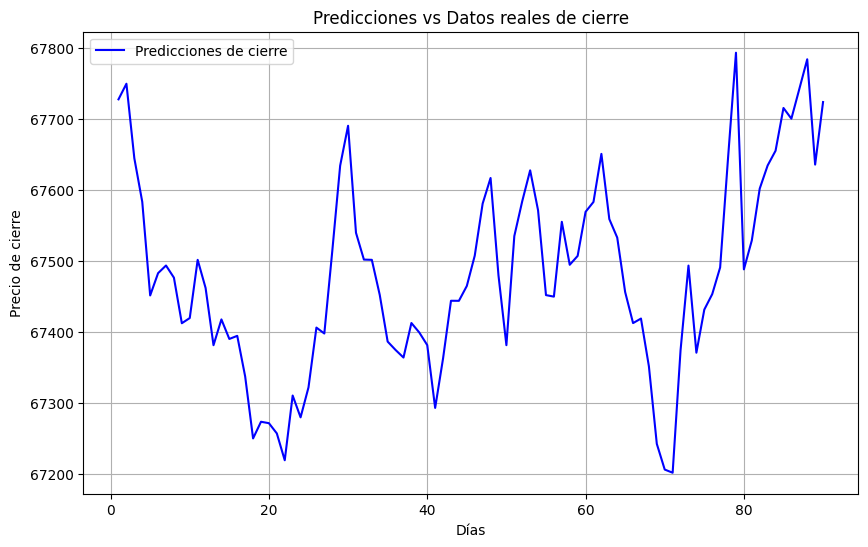

In [36]:
# Convertir el generador en listas separadas de días y predicciones
predicciones = list(enumerate(reversed(predictions_close)))
days = [i + 1 for i, _ in predicciones]
predicciones = [prediccion for _, prediccion in predicciones]

# Graficar las predicciones y los datos reales
plt.figure(figsize=(10, 6))
plt.plot(days, predicciones, label='Predicciones de cierre', color='blue')
plt.title('Predicciones de cierre Linear Regressor')
plt.xlabel('Días')
plt.ylabel('Precio de cierre')
plt.legend()
plt.grid(True)
plt.show()


In [37]:
# Asumiendo que tienes una columna 'date'
prediction_dates = pd.date_range(start=last_date, periods=prediction_days)

# Crear un DataFrame para almacenar las predicciones con fechas
predictions_df = pd.DataFrame({'Fecha': prediction_dates, 'Predicción de Cierre': reversed(predictions_close)})

# Mostrar las predicciones en forma de DataFrame
print(predictions_df)


                 Fecha  Predicción de Cierre
0  2024-05-29 16:50:00          67727.945551
1  2024-05-30 16:50:00          67749.926769
2  2024-05-31 16:50:00          67644.896688
3  2024-06-01 16:50:00          67583.606036
4  2024-06-02 16:50:00          67451.739772
..                 ...                   ...
85 2024-08-22 16:50:00          67700.715172
86 2024-08-23 16:50:00          67742.408081
87 2024-08-24 16:50:00          67784.323750
88 2024-08-25 16:50:00          67636.047360
89 2024-08-26 16:50:00          67724.142913

[90 rows x 2 columns]


In [38]:
# Realizar validación cruzada con 5 folds
scores = cross_val_score(lin_close, X_scaled, y_close, cv=5, scoring='neg_mean_squared_error')

# Convertir puntuaciones a positivas
mse_scores = -scores

# Mostrar los resultados de la validación cruzada
print("Resultados de la validación cruzada (MSE):")
print(mse_scores)
print("MSE promedio:", mse_scores.mean())

Resultados de la validación cruzada (MSE):
[1803.99071299 1032.34391    1181.56156852 2150.19589548  990.32168321]
MSE promedio: 1431.6827540388167


In [39]:
# Construir el modelo de red neuronal
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Capa de salida sin función de activación para la regresión
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
history = model.fit(X_train, y_close_train, epochs=50, batch_size=32, validation_split=0.2)

# Evaluar el modelo en el conjunto de prueba
loss = model.evaluate(X_test, y_close_test)
print("Pérdida en el conjunto de prueba:", loss)

# Realizar predicciones
predictions_nn = model.predict(real_data_scaled)

# Mostrar las predicciones
print("\nPredicciones de Red Neuronal:")
for i, prediction in enumerate(reversed(predictions_nn)):
    print(f"Predicción para el día {i+1}: {prediction[0]}")

Epoch 1/50
138/138 [==============================] - 2s 5ms/step - loss: 4327617536.0000 - val_loss: 4332249088.0000
Epoch 2/50
138/138 [==============================] - 1s 4ms/step - loss: 4310303232.0000 - val_loss: 4296422400.0000
Epoch 3/50
138/138 [==============================] - 0s 3ms/step - loss: 4244229632.0000 - val_loss: 4196258304.0000
Epoch 4/50
138/138 [==============================] - 0s 3ms/step - loss: 4099910144.0000 - val_loss: 4007404800.0000
Epoch 5/50
138/138 [==============================] - 0s 3ms/step - loss: 3858630656.0000 - val_loss: 3717788160.0000
Epoch 6/50
138/138 [==============================] - 0s 3ms/step - loss: 3516065792.0000 - val_loss: 3331720192.0000
Epoch 7/50
138/138 [==============================] - 0s 3ms/step - loss: 3085594368.0000 - val_loss: 2869611776.0000
Epoch 8/50
138/138 [==============================] - 0s 3ms/step - loss: 2594550528.0000 - val_loss: 2365589248.0000
Epoch 9/50
138/138 [==============================] - 0s

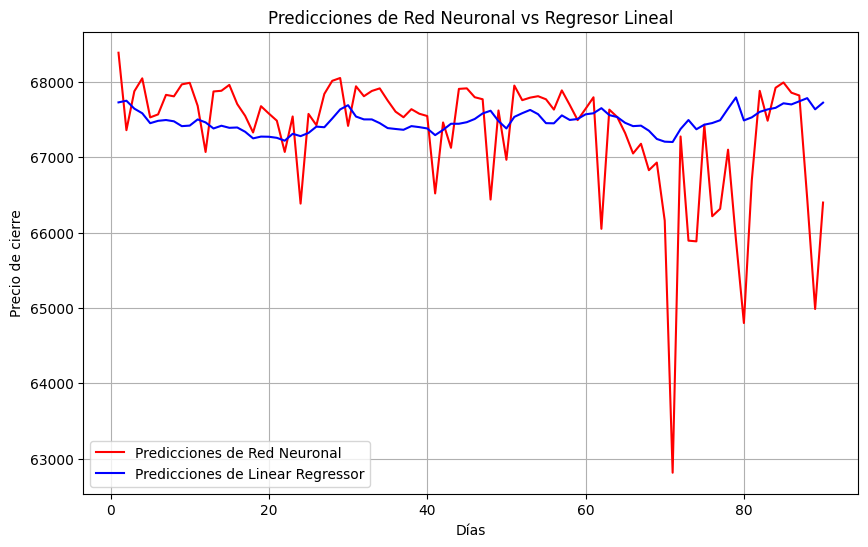

In [40]:
# Obtener los días reales para la predicción
days = range(1, prediction_days + 1)
predicciones_nn = [prediccion for _, prediccion in enumerate(reversed(predictions_nn))]

# Graficar las predicciones y los datos reales
plt.figure(figsize=(10, 6))
plt.plot(days, predicciones_nn, label='Predicciones de Red Neuronal', color='red')
plt.plot(days, predicciones, label='Predicciones de Linear Regressor', color='blue')
plt.title('Predicciones de Red Neuronal vs Regresor Lineal')
plt.xlabel('Días')
plt.ylabel('Precio de cierre')
plt.legend()
plt.grid(True)
plt.show()


In [41]:
# Load historical data
historical_data = pd.read_csv('D:/iqrobot/btcusdt_data.csv')

# Convert 'datetime' column to datetime type
historical_data['datetime'] = pd.to_datetime(historical_data['datetime'])

# Create the candlestick trace
candlestick = go.Candlestick(x=historical_data['datetime'],
                             open=historical_data['open'],
                             high=historical_data['high'],
                             low=historical_data['low'],
                             close=historical_data['close'],
                             name='Candlestick')

# Create the volume trace
volume = go.Bar(x=historical_data['datetime'],
                y=historical_data['volume'],
                name='Volume',
                marker_color='rgba(31,119,180,0.5)')

# Create the figure object
fig = go.Figure(data=[candlestick, volume])

# Update layout for better interactivity
fig.update_layout(xaxis_rangeslider_visible=True,
                  title='Interactive Candlestick Chart with Volume',
                  xaxis_title='Date',
                  yaxis_title='Price',
                  template='plotly_dark')
# Limit y-axis to 100k
fig.update_yaxes(range=[0, 90000])


# Show the interactive chart
fig.show()
